Observations:
* struggle with the standard tradeoff between matplotlib and Seaborn 
* more specifically, in order to group items:
    * matplotlib requires manually grouping via group_by
    * sns on the other hand, offers "hue" which allows splitting by group

* Inspired by this [Blog Post by Michael Taverner](https://michael-taverner.medium.com/beautifully-annotated-line-plots-in-python-with-labellines-46376f6eaa1b)

In [ ]:
#pip install matplotlib-label-lines

In [1]:
# Standard imports

#standard
import pandas as pd
#import random
from datetime import datetime
from pandasql import sqldf
pysqldf = lambda q: sqldf(q,globals())

#Viz
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [2]:
# Unique Tool

from labellines import labelLines

In [3]:
# sns_data_sets = sns.get_dataset_names()

# for data_set in sns_data_sets:
#     print(data_set)

In [4]:
df = sns.load_dataset('taxis')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pickup           6433 non-null   object 
 1   dropoff          6433 non-null   object 
 2   passengers       6433 non-null   int64  
 3   distance         6433 non-null   float64
 4   fare             6433 non-null   float64
 5   tip              6433 non-null   float64
 6   tolls            6433 non-null   float64
 7   total            6433 non-null   float64
 8   color            6433 non-null   object 
 9   payment          6389 non-null   object 
 10  pickup_zone      6407 non-null   object 
 11  dropoff_zone     6388 non-null   object 
 12  pickup_borough   6407 non-null   object 
 13  dropoff_borough  6388 non-null   object 
dtypes: float64(5), int64(1), object(8)
memory usage: 703.7+ KB


In [6]:
df['pickup'] = pd.to_datetime(df['pickup'])
df['year'] = df['pickup'].dt.year
df['month'] = df['pickup'].dt.month
df['date'] = df['pickup'].dt.date

In [7]:
### Cleaning

df = df.loc[df['month']==3]

df.sort_values(by='pickup', ascending = True, inplace = True)

In [8]:
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,year,month,date
884,2019-03-01 00:03:29,2019-03-01 00:13:32,3,2.16,10.0,2.0,0.0,15.8,yellow,credit card,Lincoln Square East,Upper East Side North,Manhattan,Manhattan,2019,3,2019-03-01
2882,2019-03-01 00:08:32,2019-03-01 00:29:47,3,7.35,22.5,1.0,0.0,27.3,yellow,credit card,East Chelsea,Mott Haven/Port Morris,Manhattan,Bronx,2019,3,2019-03-01
4212,2019-03-01 00:15:53,2019-03-01 00:47:58,1,7.00,25.5,7.3,0.0,36.6,yellow,credit card,West Village,Astoria,Manhattan,Queens,2019,3,2019-03-01
661,2019-03-01 00:29:22,2019-03-01 00:32:48,4,0.74,4.5,1.0,0.0,9.3,yellow,credit card,Meatpacking/West Village West,Meatpacking/West Village West,Manhattan,Manhattan,2019,3,2019-03-01
5917,2019-03-01 00:30:59,2019-03-01 00:37:39,2,1.35,7.0,0.0,0.0,8.3,green,cash,Astoria,Queensbridge/Ravenswood,Queens,Queens,2019,3,2019-03-01


In [9]:
borough_group_df = df.groupby(by=['date','pickup_borough'], as_index=False).sum()

In [10]:
boroughs = borough_group_df["pickup_borough"].unique() 
print(boroughs)

['Bronx' 'Brooklyn' 'Manhattan' 'Queens']


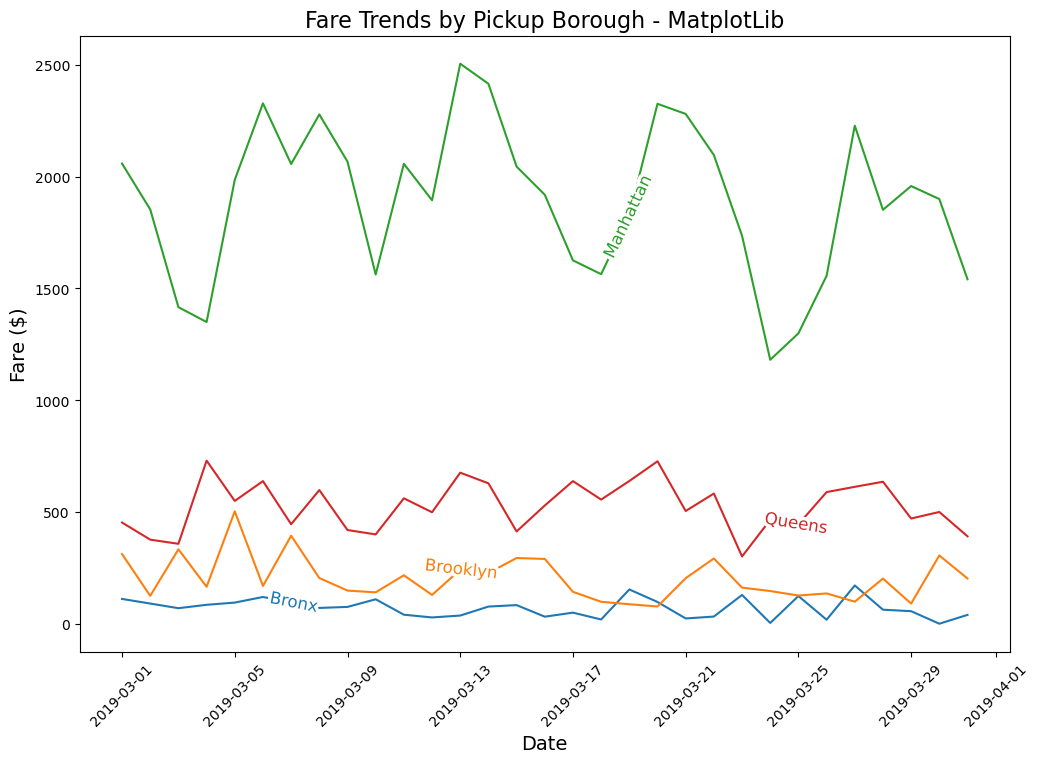

In [14]:
### Matplot Lib Version
plt.figure(figsize=(12, 8)) 

lines = []

for borough in boroughs:
    subset = borough_group_df[borough_group_df["pickup_borough"] == borough]
    line, = plt.plot(subset["date"], subset["fare"], label=borough)  # Store the line object | Comma unpacks and only stores the first element of the list ]
    lines.append(line)

# Label the lines directly
labelLines(lines, align=True, fontsize=12)  # Automatically place labels on lines

# Formatting
plt.title("Fare Trends by Pickup Borough - MatplotLib", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Fare ($)", fontsize=14)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
#plt.grid(True)

plt.show()

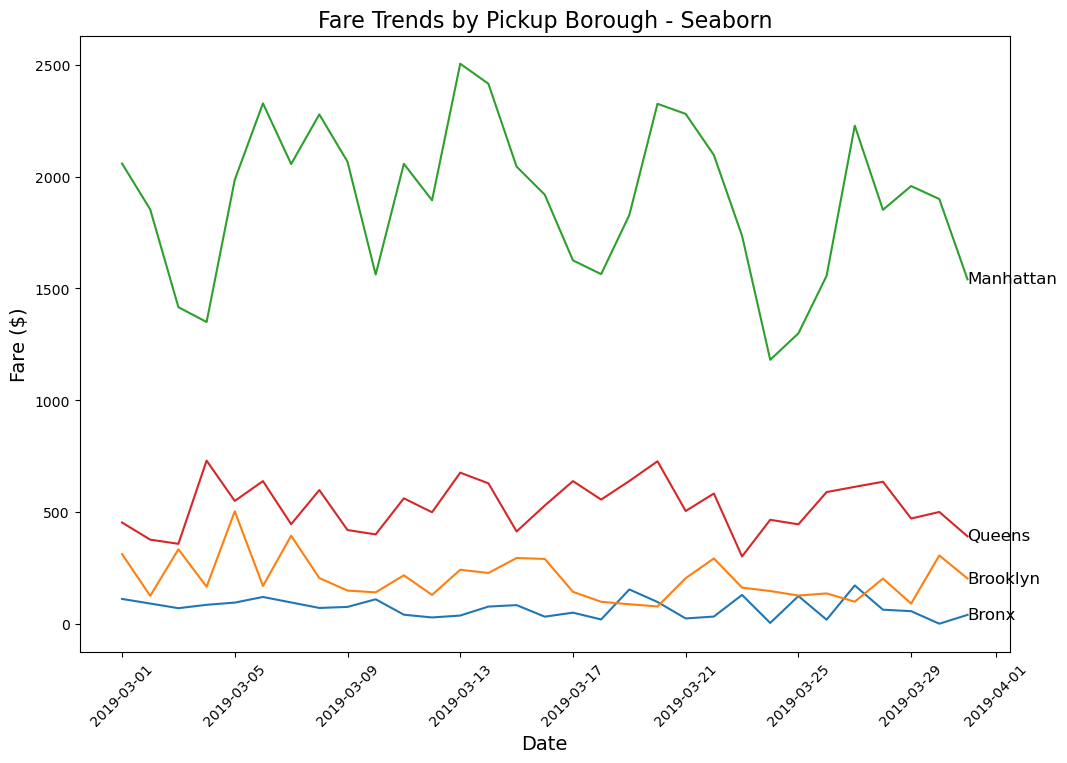

In [13]:
#SNS Version
plt.figure(figsize=(12, 8))  
ax = sns.lineplot(data=borough_group_df, x="date", y="fare", hue="pickup_borough", legend=False)

# Get unique boroughs for labeling
boroughs = borough_group_df["pickup_borough"].unique()

# Add labels to the rightmost point of each line
for borough in boroughs:
    subset = borough_group_df[borough_group_df["pickup_borough"] == borough]
    last_date = subset["date"].iloc[-1]  # Get last date value
    last_fare = subset["fare"].iloc[-1]  # Get last fare value

    plt.text(last_date, last_fare, borough, fontsize=12, verticalalignment="center")  # Add label

# Formatting
plt.title("Fare Trends by Pickup Borough - Seaborn", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Fare ($)", fontsize=14)
plt.xticks(rotation=45)
#plt.grid(True)

plt.show()